In [1]:
import numpy as np
import pandas as pd 
from pathlib import Path
from multiprocessing import Pool

import matplotlib.pyplot as plt
%matplotlib widget

import seaborn as sns

import plotly
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay
from sklearn.metrics import f1_score, balanced_accuracy_score, average_precision_score, confusion_matrix
from scipy.stats import gaussian_kde, linregress
from scipy.optimize import minimize_scalar

from tqdm.auto import tqdm
tqdm.pandas()

THRESHOLD = 0.222

In [2]:
# Load predictions

output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')
pred_path = output_path / '37_mm4_transductif-2025-12-02_12-47' / 'predictions-probs.csv'
predictions = pd.read_csv(pred_path, index_col='survey_id')

predictions_sr = (predictions > THRESHOLD).sum(axis=1)
predictions_prev = (predictions > THRESHOLD).sum(axis=0)

In [3]:
# Load targets

input_path = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common.csv') # _split.csv')
fulldf = pd.read_csv(input_path, index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})
targets = fulldf.loc[fulldf['subset'] == 'test', predictions.columns]
#targets = fulldf.loc[:,predictions.columns]

# Test dataset summary
targets_sr = (targets > 0).sum(axis=1)
targets_pres = (targets > 0).astype(int)
targets_prev = (targets > 0).sum(axis=0)
targets_bm = targets.sum(axis=1)
#species_bm = fulldf.loc[fulldf['subset'] == 'test',fulldf.columns[-1718:-1]].sum(axis=0)

## Dataset stats

In [13]:
allspeciesnames = fulldf.columns[-1797:-1]
fulltargets = fulldf[allspeciesnames]
allspecies_prev = (fulltargets > 0).sum(axis=0) / fulltargets.shape[0]
allspecies_bm = fulltargets.sum(axis=0)
 

In [71]:
allspecies_prev.describe()

count    1796.000000
mean        0.010680
std         0.028970
min         0.000036
25%         0.000182
50%         0.001294
75%         0.008055
max         0.478041
dtype: float64

## Species richness threshold

In [4]:
output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')
pred_path = output_path / '26_hum_env_dhw_bathy_common_pa-2025-11-10_16-31' / 'predictions-probs-trainval.csv'
predictions = pd.read_csv(pred_path, index_col='survey_id')

In [6]:
# Load targets

p = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common.csv')
fulldf = pd.read_csv(p, index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})
targets = fulldf.loc[fulldf['subset'] == 'val', predictions.columns]

# Test dataset summary
targets_sr = (targets > 0).sum(axis=1)
targets_pres = (targets > 0).astype(int)
targets_prev = (targets > 0).sum(axis=0)

In [4]:
predictions = predictions.loc[targets.index]

In [7]:
# Find best threshold for species richness

def rvalue(thres, df, target_sr):
    sr = (df > thres).astype(int).sum(axis=1)
    
    return np.abs(sr.mean() - target_sr.mean())

    # a = linregress(target_sr, sr)
    # return -a.rvalue


threshold = minimize_scalar(rvalue, args=(predictions, targets_sr),method='Bounded', bounds=(0,1))['x']
print(threshold)

0.27682781051290617


## Outputs visualization

#### Species richness

In [14]:
print(linregress(targets_sr, predictions_sr))

LinregressResult(slope=0.9006319539203141, intercept=2.721095854488034, rvalue=0.7879205214294985, pvalue=0.0, stderr=0.0100032680049999, intercept_stderr=0.2774968012985377)


In [16]:
fig = px.scatter(
    x=np.log(1+targets_sr), y=np.log(1+predictions_sr),
    marginal_y='violin', marginal_x='violin'
)

fig.update_layout(width=800, height=800)
fig.show()

[Text(0.5, 0, 'Ground truth species richness (logged)'),
 Text(0, 0.5, 'Predicted species richness (logged)')]

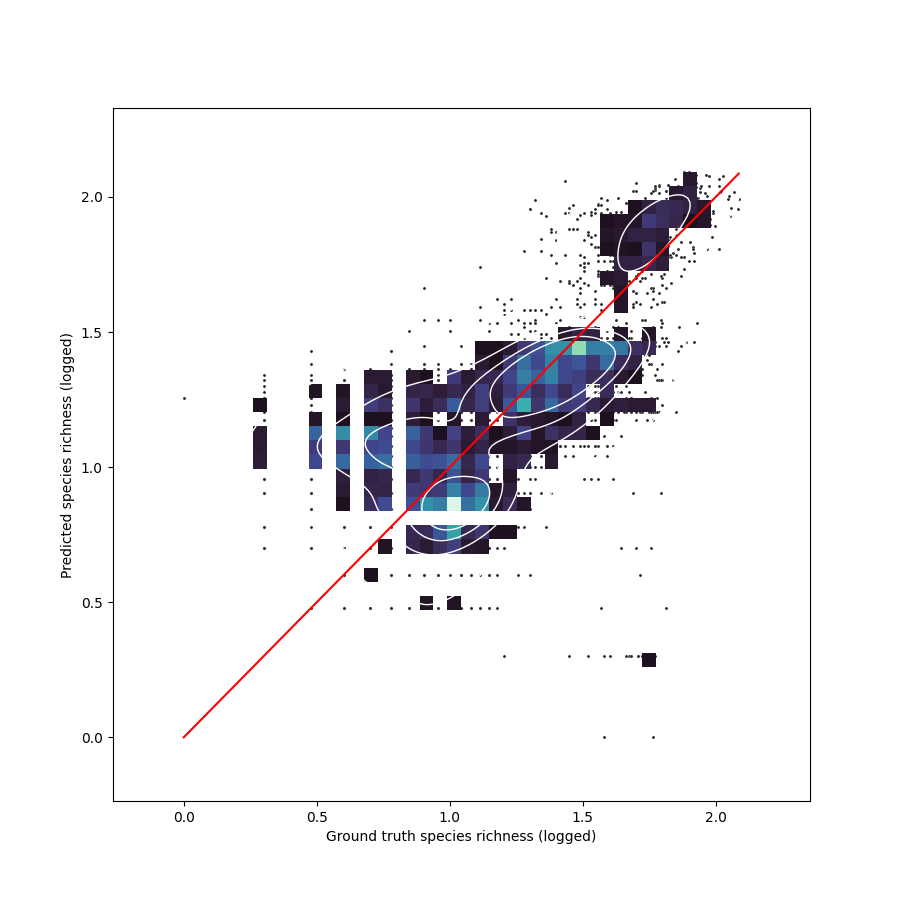

In [17]:
x, y = np.log10(1+targets_sr), np.log10(1+predictions_sr)

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel='Ground truth species richness (logged)', ylabel='Predicted species richness (logged)')

#### Total biomass

In [4]:
pred_path = output_path / '38_mm4_transductif_reg-2025-12-17_15-41' / 'predictions-biomass.csv'
predictions = pd.read_csv(pred_path, index_col='survey_id')
pred_biomass = np.exp(predictions) - 1
total_bm_pred = pred_biomass.sum(axis=1)

In [ ]:
print(linregress(targets_bm, total_bm_pred))

LinregressResult(slope=0.013136253010742073, intercept=6.124915333338682, rvalue=0.6213009752218444, pvalue=0.0, stderr=0.00023545174932439078, intercept_stderr=0.29795118322791575)


In [ ]:
x, y = np.log10(1+targets_sr), np.log10(1+predictions_sr)

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel='Ground truth species richness (logged)', ylabel='Predicted species richness (logged)')

#### Confusion matrix

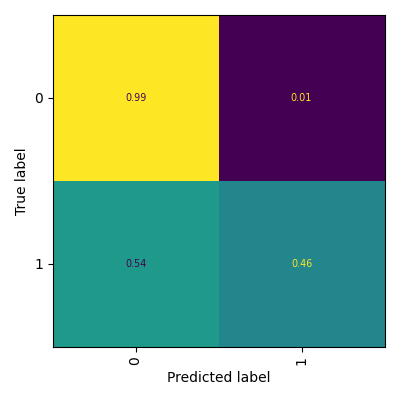

In [8]:
cm = confusion_matrix(targets_pres.to_numpy().flatten(), (predictions>THRESHOLD).to_numpy().flatten(), labels=(0,1), normalize = 'true')
cm = cm.round(2)

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=(0,1))
disp.plot(xticks_rotation = 'vertical', colorbar = False, text_kw={'fontsize': 'x-small'},ax=ax)
plt.tight_layout()
plt.show()
#plt.savefig(pred_path.parent / 'confusion_matrix.png')


#### F1 by site

In [9]:
# F1 by site

f1scores = []
test_df = fulldf[fulldf['subset'] == 'test']

for site in test_df['site_code'].unique():
    surveys = test_df[test_df['site_code'] == site].index
    lat, lon = test_df.loc[surveys[0], 'latitude'], test_df.loc[surveys[0], 'longitude']
    preds = (predictions > THRESHOLD).astype(float).loc[surveys].to_numpy().flatten()
    targets = (test_df != 0).astype(float).loc[surveys, predictions.columns].to_numpy().flatten()
    f1 = f1_score(targets, preds)
    f1scores.append({'site':site, 'f1':f1, 'lat':lat, 'lon':lon})

pd.DataFrame(f1scores).to_csv(pred_path.parent / 'f1_by_site_new.csv')


In [10]:
f1scores = pd.DataFrame(f1scores)
f1scores.describe()
f1scores['size'] = 5

In [11]:
import plotly.express as px

fig = px.scatter_map(f1scores, lat='lat',lon='lon', color='f1', height = 1100, width = 1200,
                     center={'lat':-28, 'lon':133}, zoom=4, size='size', opacity=0.2,
                     color_continuous_scale=px.colors.sequential.Inferno, map_style='light')
fig.show()

#### Embedding (clustering)

In [16]:
pred_path = output_path / '26_hum_env_dhw_bathy_common_pa-2025-11-10_16-31' / 'predictions-probs.csv'
emb = np.load(pred_path.parent / 'embedding.npy')

pred_path = output_path / '37_mm4_transductif-2025-12-02_12-47' / 'predictions-probs.csv'
td_emb = np.load(pred_path.parent / 'embedding.npy')

In [18]:
from sklearn.decomposition import PCA

test_df = fulldf[fulldf['subset'] == 'test']

pca = PCA(n_components=3)
pca.fit(emb)
pca_emb = pca.transform(emb)

td_pca = PCA(n_components=3)
td_pca.fit(td_emb)
td_pca_emb = td_pca.transform(td_emb)

pca_pd = pd.DataFrame(pca_emb, columns=['pc1', 'pc2', 'pc3'], index = test_df.index)
td_pca_pd = pd.DataFrame(td_pca_emb, columns=['pc1', 'pc2', 'pc3'], index = test_df.index)

In [19]:
from sklearn.cluster import AgglomerativeClustering

n_clusters = 9

clustering = AgglomerativeClustering(n_clusters=n_clusters)
cluster_labels = clustering.fit_predict(pca_pd[['pc1', 'pc2', 'pc3']])
pca_pd['cluster_label'] = cluster_labels

td_clustering = AgglomerativeClustering(n_clusters=n_clusters)
td_cluster_labels = td_clustering.fit_predict(td_pca_pd[['pc1', 'pc2', 'pc3']])
td_pca_pd['cluster_label'] = td_cluster_labels

In [30]:
#fig = px.scatter_3d(pca_pd, x='pc1', y='pc2', z='pc3', color='cluster_label', height = 600, width = 800, color_continuous_scale=px.colors.sequential.Turbo)

from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=1, cols=2,specs=[[{'type': 'surface'}, {'type': 'surface'}]])

fig.add_trace(
    go.Scatter3d(x=pca_pd['pc1'], y=pca_pd['pc2'], z=pca_pd['pc3'], mode='markers',
                 marker=dict(color=pca_pd['cluster_label'], colorscale=px.colors.sequential.Turbo)),
    row=1, col=1
)

fig.add_trace(
    go.Scatter3d(x=td_pca_pd['pc1'], y=td_pca_pd['pc2'], z=td_pca_pd['pc3'], mode='markers',
                 marker=dict(color=td_pca_pd['cluster_label'], colorscale=px.colors.sequential.Turbo)),
    row=1, col=2
)

fig.update_layout(height=800, width=1400)
fig.show()

# fig.update_scenes(xaxis_title_font_color="blue",
#                   xaxis_tickfont_color="blue",
#                   yaxis_title_font_color="red",
#                   yaxis_tickfont_color="red",  
#                   zaxis_title_font_color="green",
#                   zaxis_tickfont_color="green",)


In [20]:
to_export = pd.concat([pca_pd, test_df[['site_code', 'latitude', 'longitude', 'survey_date']]], axis=1)
to_export.to_csv(pred_path.parent / 'pca.csv')

#### Embeddings (vs colors)

In [67]:
pred_path = output_path / '26_hum_env_dhw_bathy_common_pa-2025-11-10_16-31' / 'predictions-probs.csv'
emb = np.load(pred_path.parent / 'embedding.npy')

pred_path = output_path / '37_mm4_transductif-2025-12-02_12-47' / 'predictions-probs.csv'
td_emb = np.load(pred_path.parent / 'embedding.npy')

env = pd.read_csv('/data/data/malpolon/xgb/X_compound_values_mm.csv', index_col='survey_id', usecols = list(range(20)) + [59])
env.columns = ["fsle", "fsle-orientation", "bathymetry_aus", "chlorophyll", "sst", "salinity3d", "ph", "surface-current-u",
"surface-current-v", "wind-u", "wind-v", "wave-height", "oxygen", "mixed-layer-thickness",
"nitrate", "prot_level", "distance-to-port", "pop-density-log", "gravity", "dhw_max"]

ind = pd.read_csv('/data/data/RLS/eco_indicators.csv', index_col='survey_id')
ind = ind.loc[ind['subset'] == 'test'].drop(columns=['subset'])

In [75]:
from sklearn.decomposition import PCA

test_df = fulldf[fulldf['subset'] == 'test']

pca = PCA(n_components=2)
pca.fit(emb)
pca_emb = pca.transform(emb)

td_pca = PCA(n_components=2)
td_pca.fit(td_emb)
td_pca_emb = td_pca.transform(td_emb)

pca_pd = pd.DataFrame(pca_emb, columns=['pc1', 'pc2'], index = test_df.index)
td_pca_pd = pd.DataFrame(td_pca_emb, columns=['pc1', 'pc2'], index = test_df.index)

In [ ]:
# Plot vs predictors

from plotly.subplots import make_subplots
import plotly.graph_objects as go

USE_CASE = 'INDUCTIVE' ## or INDUCTIVE

if USE_CASE == 'TRANSDUCTIVE':
    data = td_pca_pd
else:
    data = pca_pd

fig = make_subplots(rows=4, cols=5, subplot_titles=env.columns,
                    horizontal_spacing = 0.02, vertical_spacing=0.04)

for i in range(len(env.columns)):
    var = env.columns[i]
    fig.add_trace(
        go.Scatter( x=data['pc1'], y=data['pc2'], mode='markers',
                    marker=dict(color=env.loc[data.index, var], colorscale='Spectral')),
        row= 1 + i // 5, col=1 + i % 5
    )

fig.update_layout(height=1200, width=1500, showlegend=False)
fig.show()

In [ ]:
# Plot vs predictors

from plotly.subplots import make_subplots
import plotly.graph_objects as go

USE_CASE = 'TRANSDUCTIVE' ## or INDUCTIVE

if USE_CASE == 'TRANSDUCTIVE':
    data = td_pca_pd
else:
    data = pca_pd

fig = make_subplots(rows=3, cols=3, subplot_titles=ind.columns,
                    horizontal_spacing = 0.05, vertical_spacing=0.05)

for i in range(len(ind.columns)):
    var = ind.columns[i]
    fig.add_trace(
        go.Scatter( x=data['pc1'], y=data['pc2'], mode='markers',
                    marker=dict(color=ind.loc[data.index, var], colorscale='Spectral')),
        row= 1 + i // 3, col=1 + i % 3
    )

fig.update_layout(height=1000, width=1500, showlegend=False)
fig.show()

## Best species

#### Calculate species-wise metric

In [9]:
# Calculate average precision
scorename = 'f1' # / AP

if scorename == 'AP':
    ap = average_precision_score(targets_pres.to_numpy(), predictions.to_numpy(), average=None)
    scores = pd.DataFrame({"AP":ap}, index=predictions.columns)
elif scorename == 'f1':
    dic = {}
    for s in predictions.columns:
        preds = (predictions[s] > THRESHOLD).astype(float).to_numpy().flatten()
        targ = (targets[s] != 0).astype(float).to_numpy().flatten()
        f1 = f1_score(targ, preds)
        dic[s] = {'f1': f1}
    scores = pd.DataFrame(dic).T

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/data/venvs/copmari

In [10]:
scores.sort_values(ascending=False, by=scorename, inplace = True)
scores.to_csv(pred_path.parent / f'all-test-{scorename}.csv')

In [47]:
scores.sort_values(ascending=False, by=scorename, inplace = True)
scores#.to_csv(pred_path.parent / f'top59-test-{scorename}.csv')
len(scores[(scores['f1'] <= 0.5) & (scores['f1'] > 0.2)])#.to_csv(pred_path.parent / f'mid111-val-{scorename}.csv')
len(scores[scores['f1'] > 0.5])

57

#### Study prevalent species

In [15]:
f1 = pd.read_csv(pred_path.parent / f'testF1--TH=0.222--.4rank=137.csv', index_col=0)
f1[:10]

,f1
Notolabrus parilus,0.989930
Coris auricularis,0.978824
Notolabrus tetricus,0.953336
Notolabrus gymnogenis,0.944072
Parma mccullochi,0.909552
Pomacentrus moluccensis,0.855950
Halichoeres melanurus,0.845029
Morwong fuscus,0.839840
Acanthochromis polyacanthus,0.801001
Scolopsis bilineata,0.799582


#### Plot F1 against prevalence

In [24]:
df = pd.concat([f1, allspecies_prev.loc[f1.index].rename('prev'), allspecies_bm.loc[f1.index].rename('bm')], axis=1)

df['logprev'] = np.log10(1+df['prev'])
fig = px.scatter(df,
                 x='logprev',
                 y='f1',
                 size='bm',
                 template='simple_white',
                 hover_name=list(df.index),
                 width=1200,
                 height=800)

fig.show()

In [73]:
df.loc[df['prev'] > 0.01,'f1'].describe()

count    406.000000
mean       0.250565
std        0.229046
min        0.000000
25%        0.029461
50%        0.200719
75%        0.417998
max        0.960365
Name: f1, dtype: float64

In [26]:
# part of biomass correctly explained
df.loc[df['f1'] > 0.3, 'bm'].sum() / allspecies_bm.sum()

0.5067865309219742

In [12]:
# Save to file

best_species = aps.iloc[0:100]
best_pred_path = pred_path.parent / 'predictions-probs-best100.csv'

df1 = predictions[list(best_species.index)]
df2 = fulldf[['latitude', 'longitude', 'depth', 'eventDate']]
pd.concat([df2, df1], axis=1, join="inner").to_csv(best_pred_path)

#### Create input files for additional training (best10 modality)

In [10]:
bestpredspath = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/best30')

def save_line(row):
    np.save(bestpredspath / f"{row.name}.npy", row.values.astype(float))

In [11]:
best_pred_path = pred_path.parent / 'predictions-probs-best30.csv'
best_pred = pd.read_csv(best_pred_path, index_col='survey_id')
best_species = best_pred.columns[4:]
groundtruth = fulldf.loc[fulldf['subset'] != 'test' , best_species] > 0
to_save = pd.concat([groundtruth, best_pred[best_species]])
to_save.progress_apply(save_line, axis=1)

  0%|          | 0/27437 [00:00<?, ?it/s]

survey_id
923400045    None
923400036    None
923400037    None
923400043    None
923402703    None
             ... 
712300818    None
712301159    None
712301158    None
712301157    None
712301156    None
Length: 27437, dtype: object

#### Plotting

In [ ]:
# Species-specific confusion matrices

i = 0
for s in list(best_species.index):

    PrecisionRecallDisplay.from_predictions(targets_pres[s].to_numpy(), predictions[s].to_numpy())
    plt.savefig(pred_path.parent / 'PR-curves' / f"{s}.png")

    # numbins = 2

    # cm = confusion_matrix((targets[s]>0).to_numpy().astype(int), (predictions[s]>0.5).to_numpy().astype(int), labels=range(numbins), normalize = 'true')
    # cm = cm.round(3)

    # fig, ax = plt.subplots(figsize=(6, 6))
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"absent (N={len(targets) - targets_prev[s]})", f"present (N={targets_prev[s]})"])
    # disp.plot(xticks_rotation = 'vertical', colorbar = False, text_kw={'fontsize': 'x-small'},ax=ax, cmap = 'Blues')
    # disp.ax_.set_title(f"{s} - AP: {best_species.loc[s,'AP']:.2f},\n prevalence = {targets_prev[s]}")
    # plt.tight_layout()
    # plt.savefig(pred_path.parent / 'cm' / f'{i}_{s}.png')
    # #plt.show()
    # i += 1

In [ ]:
best_species = pd.read_csv(pred_path.parent / 'best_species_300.csv', index_col = 0)
best_species['genus'] = best_species.index.to_series().apply(lambda x: str(x).split()[0])

px.scatter(best_species, x='prev', y='AP', color='genus')

NameError: name 'pred_path' is not defined

In [12]:
output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')

baseline = pd.read_csv(output_path / '18_humenv_dhw_cat_pa-2025-07-11_16-53-preds' / 'all-test-f1.csv', index_col = 0)
baseline.reset_index(inplace=True)
fig = px.line(baseline, x=baseline.index, y='f1', template = 'simple_white',
           width = 800, height=600)

fig.update_layout(
    xaxis_title='Species rank',
    yaxis_title='F1 score')


## Interpretability

In [ ]:
best_species = pd.read_csv(pred_path.parent / 'best_species.csv', index_col = 0)
species = list(best_species.index)
ig_path = pred_path.parent / 'integrated_gradients'

labels = ["fsle", "fsle-orientation", "bathymetry_aus", "chlorophyll", "sst", "salinity3d", "ph", "surface-current-u",
"surface-current-v", "wind-u", "wind-v", "wave-height", "oxygen", "mixed-layer-thickness",
"nitrate", "prot_level", "distance-to-port", "pop-density-log", "gravity"]

#### Per variable density

In [ ]:
colors = plotly.colors.qualitative.Light24

def produce_charts(speci):

    presences = []
    absences = []
    for survey_id in list(targets.index):

        ig = np.load(ig_path / speci / f"ig_{survey_id}.npy")

        abs_ig = np.abs(ig).squeeze()
        averages = abs_ig.mean(axis=(1,2))

        if fulldf.loc[survey_id, s] > 0:
            presences.append(averages)
        else:
            absences.append(averages)

    
    presences = np.vstack(presences)
    absences = np.vstack(absences)

    p = pd.DataFrame(presences)
    a = pd.DataFrame(absences)
    a.columns = labels
    p.columns = labels

    fig = make_subplots(rows=2, cols=1, subplot_titles=("Presence", "Absence"))

    # Plot density for each column
    for i in range(len(a.columns)):
        column = a[s].columns[i]

        density = gaussian_kde(p[column])
        xs = np.linspace(p[column].min(), p[column].max(), 200)
        ys = density(xs)
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', name=column, line = dict(color=colors[i])), row=1, col=1)

        density = gaussian_kde(a[column])
        xs = np.linspace(a[column].min(), a[column].max(), 200)
        ys = density(xs)
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', name=column, line = dict(color=colors[i])), row=2, col=1)

    # Update layout
    fig.update_layout(title=speci,
                    xaxis_title='Value',
                    yaxis_title='Density',
                    template='plotly_white',
                    height = 800)

    # Show plot
    fig.update_yaxes(range=[0, 600]) 
    fig.update_xaxes(range=[0, 0.03]) 
    fig.write_image(pred_path.parent / "ig_densities" / f"{s}.png")

In [ ]:
with Pool(processes=18) as pool:
        results = pool.map(produce_charts, species)

#### Summary chart

In [ ]:
series_dict = {}

for i in range(len(species)):
    s = species[i]
    p = Path(output_path / ig_name / "ig_stats" / f"{s}_pres.csv")
    if p.exists():
        df = pd.read_csv(p, index_col = 0)
        series_dict[s] = df['50%']

df = pd.concat(series_dict, axis = 1).T
df.sort_values(ascending=False, by = 'bathymetry_aus', inplace = True)
fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(df.T, ax = ax, cbar=False, cmap='YlOrRd')
plt.tight_layout()

## Compare checkpoints

#### FP / FN

In [45]:
checkpoints = {'9_env_pa-2025-02-04_16-46-preds' : 'Environment17',
               '10_sat_pa-2025-02-05_17-32-preds' : 'Satellite',
               '11_satenv_pa-2025-02-06_11-50-preds' : 'Environment + Satellite',
               '9_env_pa-2025-03-11_10-31-preds' : 'Environment15',
               '13_hum_pa-2025-03-11_10-29-preds' : 'Human activities',
               '15_humenv_cat_pa-2025-03-11_10-32-preds' : 'Environment + Human activities<br><b>monomodal</b>',
               '14_humenv_pa-2025-03-04_11-45-preds' : 'Environment + Human activities<br><b>multimodal</b>',
               '18_humenv_dhw_cat_pa-2025-05-16_12-02-preds' : 'Envhum+DHW',
               '20_humenv_best10_pa-2025-05-16_14-50-preds' : 'Envhum+Best10',
               '22_humenv_dhw_best10_pa-2025-05-16_13-47-preds': 'Envhum+DHW+Best10',
               '23_humenv_dhw_best30_pa-2025-05-21_09-48-preds': 'Envhum+DHW+Best30',
               }

checkpoints = {'18_humenv_dhw_cat_pa-2025-07-07_16-55-preds': 0,
               #'18_humenv_dhw_cat_pa-2025-07-02_16-41-preds': .011111,
            #   '18_humenv_dhw_cat_pa-2025-07-08_09-39-preds': .01,
            #    '18_humenv_dhw_cat_pa-2025-07-08_09-29-preds': .2,
            #    '18_humenv_dhw_cat_pa-2025-07-08_10-14-preds': .04,
            #   '18_humenv_dhw_cat_pa-2025-07-08_10-58-preds': .1,
            #    '18_humenv_dhw_cat_pa-2025-07-08_12-50-preds': 0.025,
            #   '18_humenv_dhw_cat_pa-2025-07-08_13-49-preds': 0.001,
            #    '18_humenv_dhw_cat_pa-2025-07-08_15-24-preds': 0.004,
            #    '18_humenv_dhw_cat_pa-2025-07-08_16-41-preds': 0.08,
            '18_humenv_dhw_cat_pa-2025-07-09_13-48-preds': 0.1,
            '18_humenv_dhw_cat_pa-2025-07-09_14-39-preds': 0.02,
            '18_humenv_dhw_cat_pa-2025-07-09_15-30-preds': 0.5,}
            # '18_humenv_dhw_cat_pa-2025-07-09_16-22-preds': 2}


points = []

for cp in checkpoints:
    try:
        pred_path = Path('/marbec-data/RLS-Australia/malpolon/outputs') / cp / 'predictions-probs.csv'
        predictions = pd.read_csv(pred_path, index_col='survey_id')
    except Exception as e:
        pred_path = Path('/marbec-data/RLS-Australia/malpolon/outputs') / cp / 'predictions.csv'
        predictions = pd.read_csv(pred_path, index_col='survey_id')
    predictions = (predictions >= THRESHOLD).astype(int)

    f1 = f1_score(targets_pres, predictions, average='weighted')
    macacc = balanced_accuracy_score(targets_pres.to_numpy().flatten(), predictions.to_numpy().flatten())
    FP = ((targets_pres == 0) & (predictions == 1)).to_numpy().sum() / (targets_pres == 0).to_numpy().sum()
    FN = ((targets_pres == 1) & (predictions == 0)).to_numpy().sum() / (targets_pres == 1).to_numpy().sum()
    points.append({'f1': f1, 'macro_acc':macacc, 'label': checkpoints[cp], 'False Positives':FP, 'False Negatives':FN})
    

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. U

In [46]:
data = pd.DataFrame(points)
data['size'] = 12

fig = px.scatter(data,
                 x='False Positives',
                 y='False Negatives',
                 color='label',
                 text='label',
                 size = 'size',
                 template='simple_white',
                 width=800,
                 height=600)

fig.update_layout(showlegend=False)
# fig.update_yaxes(   scaleanchor="x",
#                     scaleratio=1)
fig.update_traces(textposition='middle right',  textfont=dict(size=20))

data = data.sort_values(by="label")

fig.add_traces(list(px.line(data, x='False Positives', y='False Negatives').select_traces()))
fig.update(layout_coloraxis_showscale=False)

fig.show()

<Axes: >

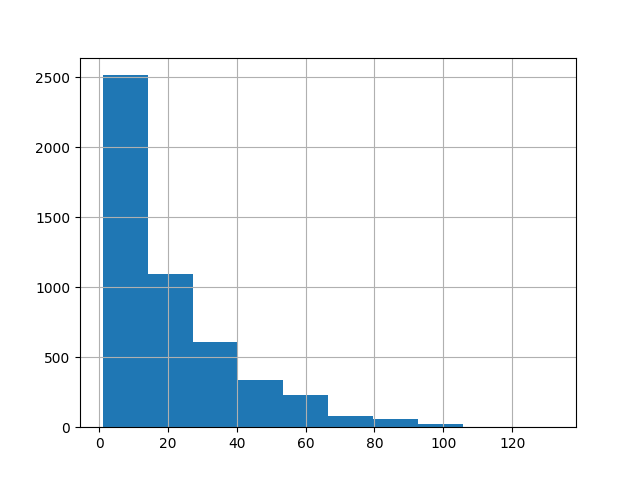

In [10]:
targets_sr.hist()

#### Bland-Altman

In [17]:
import pandas as pd
baseline = pd.read_csv(output_path / '25_humenv_dhw_common_pa-2025-09-16_11-43-preds' / 'all-test-f1.csv', index_col = 0)
finetuned = pd.read_csv(output_path / '29_humenv_dhw_common_easyish_pa-2025-10-15_13-43-preds' / 'mid111-test-f1.csv', index_col = 0)

# baseline = pd.read_csv(output_path / '25_humenv_dhw_common_pa-2025-09-16_11-43-preds' / 'all-test-f1.csv', index_col = 0)
# finetuned = pd.read_csv(output_path / '27_humenv_dhw_common_easy_pa-2025-10-14_12-50-preds' / 'top59-test-f1.csv', index_col = 0)

baseline = baseline.loc[finetuned.index]

In [9]:
baseline.describe()

,f1
count,111.000000
mean,0.273761
std,0.218548
min,0.000000
25%,0.099066
50%,0.224299
75%,0.404571
max,0.929263


array([[<Axes: title={'center': 'f1'}>]], dtype=object)

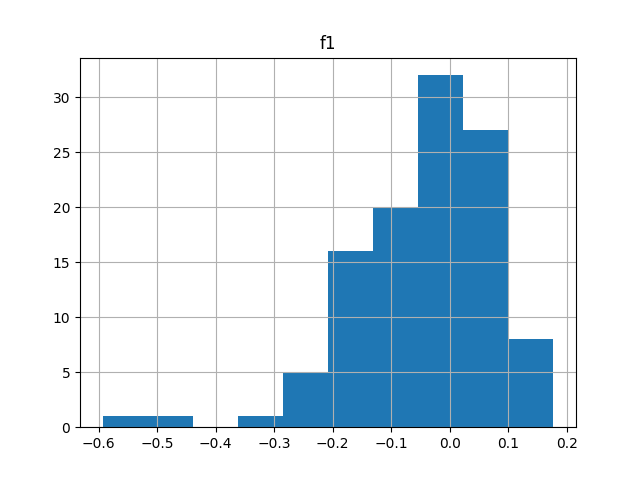

In [13]:
(finetuned - baseline).hist()

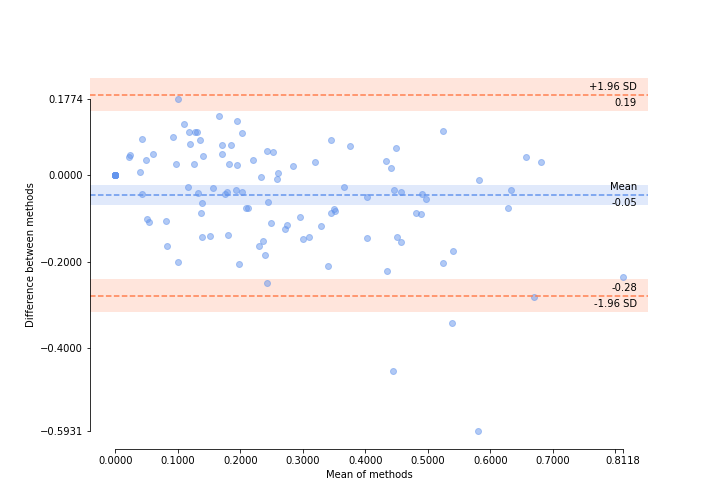

In [18]:
import pyCompare

pyCompare.blandAltman(finetuned['f1'].values, baseline['f1'].values)

## Traits

#### Load traits

In [7]:
traits = pd.read_csv('/data/data/RLS/traits.csv', index_col=0)

iucn_stats = {s: traits['IUCN_category'].get(s, 'NA') for s in predictions.columns}
iucn_encr = pd.Series([(iucn_stats[s] in ['CR', 'EN'])*1 for s in predictions.columns], index = predictions.columns)

trop_level = {s: traits['Troph'].get(s, 'NA') for s in predictions.columns}
trop_troph = pd.Series([trop_level[s] if trop_level[s] != 'NA' else None for s in predictions.columns], index = predictions.columns)

iucnL_stats = {s: traits['IUCN_inferred_Loiseau23'].get(s, 'NA') for s in predictions.columns}
iucnL_encr = pd.Series([(iucnL_stats[s] == 'Threatened')*1 for s in predictions.columns], index = predictions.columns)


#### Calculate ecological indicators

In [8]:
# Traits
traits_df = pd.DataFrame()

for traitname in ['DemersPelag', 'Troph', 'IUCN_inferred_Loiseau23']:
    dic = {}
    for s in predictions.columns:
        dic[s] = traits[traitname].get(s, np.nan)
    traits_df[traitname] = pd.Series(dic)

In [9]:
def iucn_perc(row):
    present_species = row[row > 0].index
    if len(present_species) == 0:
        return 0
    return iucnL_encr.loc[present_species].sum() / len(present_species)

def av_troph(row):
    present_species = row[row > 0].index
    if len(present_species) == 0:
        return 0
    return trop_troph.loc[present_species].mean()

def std_troph(row):
    present_species = row[row > 0].index
    if len(present_species) == 0:
        return 0
    return trop_troph.loc[present_species].std()

In [13]:
## Groundtruth
 
out = fulldf[['latitude', 'longitude', 'depth', 'subset']]
out = out.assign(year=pd.to_datetime(fulldf['eventDate']).dt.year)
month = pd.to_datetime(fulldf['eventDate']).dt.month - 1
out['season'] = 0.5-0.5*np.cos(np.pi*month / 6)
out['sr'] = (fulldf[predictions.columns] > 0).sum(axis=1)
out['bm'] = np.log(1+fulldf[predictions.columns].sum(axis=1))

out['troph'] = fulldf[predictions.columns].apply(av_troph, axis=1)
out['stdtroph'] = fulldf[predictions.columns].apply(std_troph, axis=1)
out['uicn'] = fulldf[predictions.columns].apply(iucn_perc, axis=1)

# Normalize
output = pd.DataFrame()
output['eventDate'] = pd.Series('', index = out.index)
output['logsr'] = np.log(1 + out['sr'])
output['logsr'] = output['logsr'] / output['logsr'].max()
output['logbm'] = np.log(1 + out['bm'])
output['logbm'] = output['logbm'] / output['logbm'].max()
output['troph'] = out['troph'] / out['troph'].max()
output['stdtroph'] = out['stdtroph'] / out['stdtroph'].max()
output['uicn'] = out['uicn'] / out['uicn'].max()
output['subset'] = out['subset']

output.dropna().to_csv(input_path.parent / 'eco_indic_norm.csv')

In [13]:
## Predictions 
out_targets = out.loc[predictions.index]

out_preds = pd.DataFrame()
out_preds['sr'] = (predictions > THRESHOLD).sum(axis=1)
out_preds['troph'] = (predictions > THRESHOLD).apply(av_troph, axis=1)
out_preds['uicn'] = (predictions > THRESHOLD).apply(iucn_perc, axis=1)

mask = ~np.isnan(out_targets['troph']) & ~np.isnan(out_preds['troph'])

print('sr:', linregress(out_targets['sr'], out_preds['sr']))
print('troph:', linregress(out_targets.loc[mask, 'troph'], out_preds.loc[mask, 'troph']))
print('uicn:', linregress(out_targets['uicn'], out_preds['uicn']))


# # Draw a combo histogram and scatterplot with density contours
# f, ax = plt.subplots(figsize=(9, 9))
# sns.scatterplot(x=x, y=y, s=5, color=".15")
# sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
# sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
# sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')

sr: LinregressResult(slope=0.9006319539203141, intercept=2.721095854488034, rvalue=0.7879205214294985, pvalue=0.0, stderr=0.0100032680049999, intercept_stderr=0.2774968012985377)
troph: LinregressResult(slope=0.038289943140901214, intercept=3.0609297396434205, rvalue=0.045390476070371645, pvalue=0.0013983643507139007, stderr=0.011977592547818385, intercept_stderr=0.03855509752289119)
uicn: LinregressResult(slope=0.4843351797230834, intercept=0.039900948263112704, rvalue=0.477029848764912, pvalue=6.143876997285547e-280, stderr=0.012681980596682026, intercept_stderr=0.0013070533623731496)


#### Plot improvement wrt traits

In [ ]:
fulldf = pd.read_csv(Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/') / 'database_common.csv', index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})

cp = '37_mm4_transductif-2025-12-02_12-47'
deep_f1 = pd.read_csv(next((output_path / cp).glob("testF1*.csv")), index_col = 0)
xgb2_f1 = pd.read_csv(Path('/data/data/malpolon/xgb') / f'xgbmm-test-f1.csv', index_col = 0)

In [ ]:
scores = pd.concat([xgb2_f1["f1"], deep_f1["f1"]], axis = 1)
names = ['XGBoost', 'TDeep']
scores.columns = names
scores.dropna(inplace=True)
scores['progress'] = (scores[names[1]] - scores[names[0]])
scores['max'] = scores[names].max(axis=1)
best_scores = scores.loc[scores['max'] > 0.4]

In [91]:
import plotly.express as px


fig = px.violin(best_scores, x=traitname, y="progress", points = 'all', color = traitname,color_discrete_sequence= px.colors.qualitative.Pastel)


fig.update_layout(
    template='simple_white',
    width = 800, height=800,
    yaxis_title='F1 delta',
    xaxis_title='',
    font=dict(size=20),
    showlegend=False)
    

fig.add_shape(type="line",
    xref="paper",
    x0=0, y0=0,
    x1=1, y1=0,
    line=dict(
        color="blue",
        width=3,
    ))

fig.show()